# Semiconductor Manufacturing Yield and Defect Prediction

This notebook is the review layer for a leakage-aware UCI SECOM analysis.
The reusable implementation lives in `src/` and the two run scripts. It
reports favourable and unfavourable results, including the failure of a
random-split threshold to transfer to a later process period.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..').resolve()
REPORTS = ROOT / 'reports'
TABLES = REPORTS / 'tables'
FIGURES = REPORTS / 'figures'

## 1. Data audit and time variation

SECOM contains 104 failures among 1,567 runs and 590 anonymised process
measurements. Failure prevalence is not stable across the collection
period, which motivates chronological evaluation rather than random
splitting alone.

,value
samples,1567
features,590
failures,104
failure_rate,0.066369
missing_cells,41951
missing_fraction,0.045375
features_over_50pct_missing,28
start_timestamp,2008-07-19T11:55:00
end_timestamp,2008-10-17T06:07:00


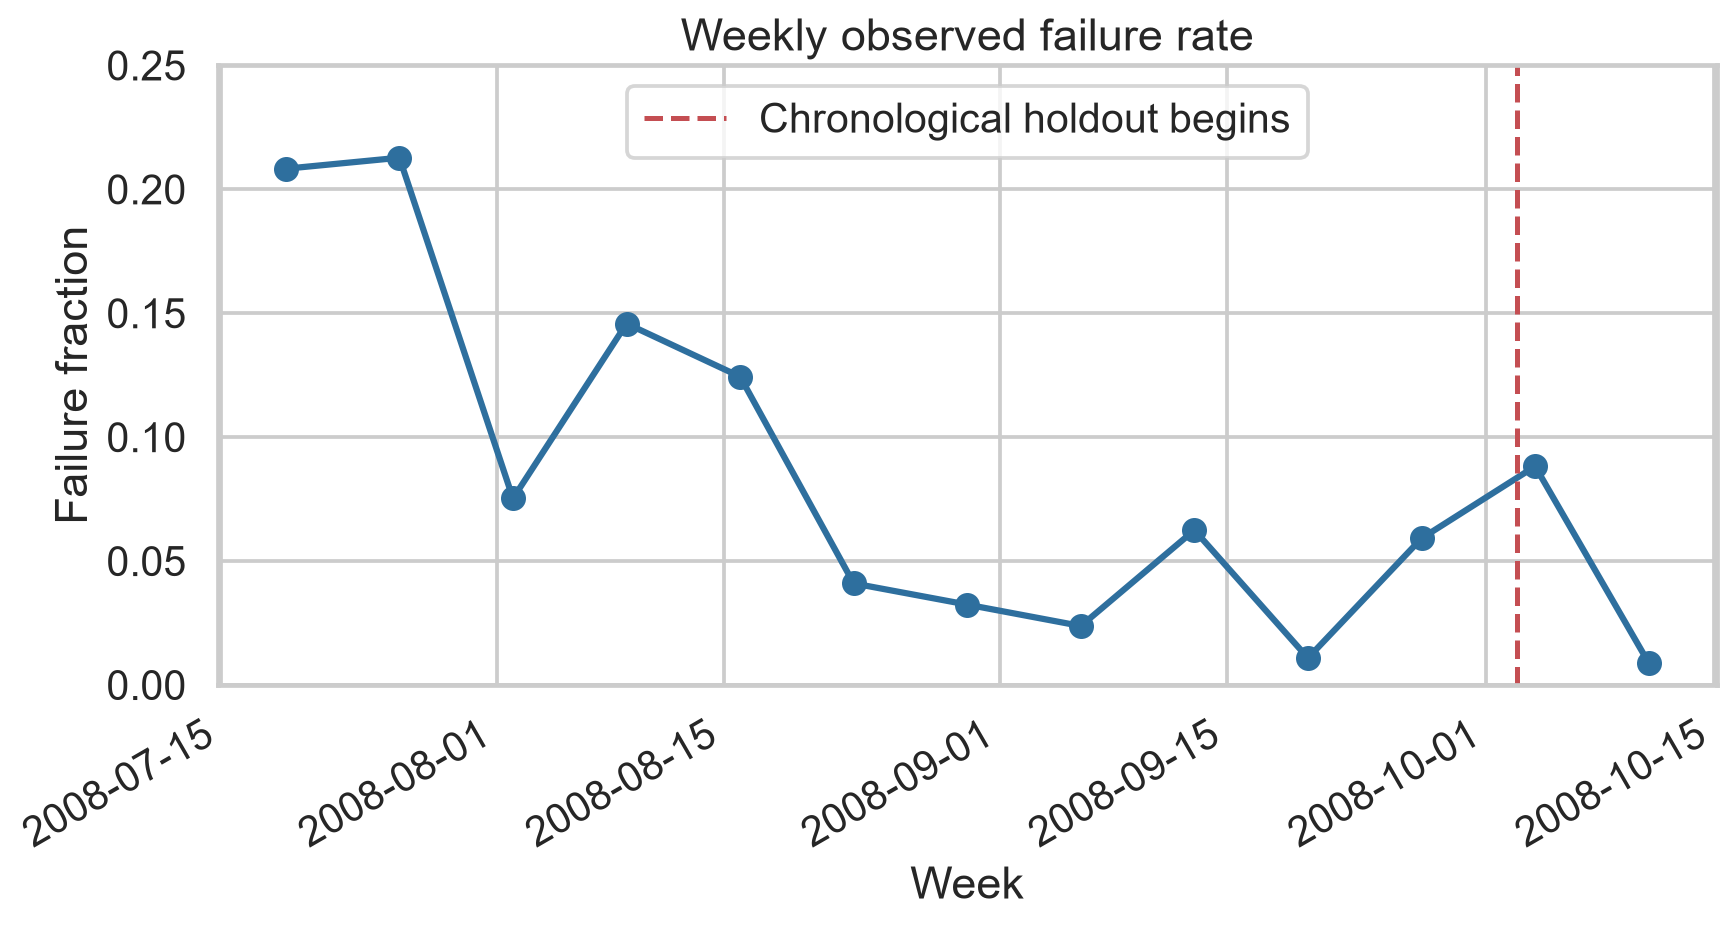

In [2]:
profile = pd.read_csv(TABLES / 'dataset_profile.csv')
display(profile.T.rename(columns={0: 'value'}))
display(Image(filename=str(FIGURES / 'weekly_failure_rate.png'), width=900))

## 2. Leakage-safe model comparison

Missingness filtering, imputation, constant-feature removal, scaling,
feature selection, PCA, and missingness indicators are fitted inside each
training fold. Models within 0.005 mean PR-AUC are treated as practical
ties to avoid selecting complexity from a negligible decimal difference.

In [3]:
comparison = pd.read_csv(TABLES / 'model_cv_comparison.csv')
comparison[['model', 'cv_pr_auc_mean', 'cv_pr_auc_std',
            'cv_roc_auc_mean', 'cv_recall_mean']].round(3)

,model,cv_pr_auc_mean,cv_pr_auc_std,cv_roc_auc_mean,cv_recall_mean
0,random_forest_missing_indicator,0.178,0.087,0.703,0.006
1,random_forest,0.178,0.081,0.707,0.018
2,logistic_selected,0.161,0.040,0.670,0.471
3,hist_gradient_boosting,0.159,0.064,0.667,0.096
4,logistic_pca,0.124,0.035,0.627,0.447


## 3. Random versus chronological holdout

Random splitting gives ROC-AUC 0.739 and PR-AUC 0.244. Training on the
earliest 80% and testing on the latest 20% reduces these to 0.616 and
0.087. The chronological result is the more deployment-like stress test.

,validation_scheme,roc_auc,pr_auc,recall,precision,review_rate
0,Random stratified,0.739,0.244,0.524,0.162,0.217
1,Chronological,0.616,0.087,0.000,0.000,0.016


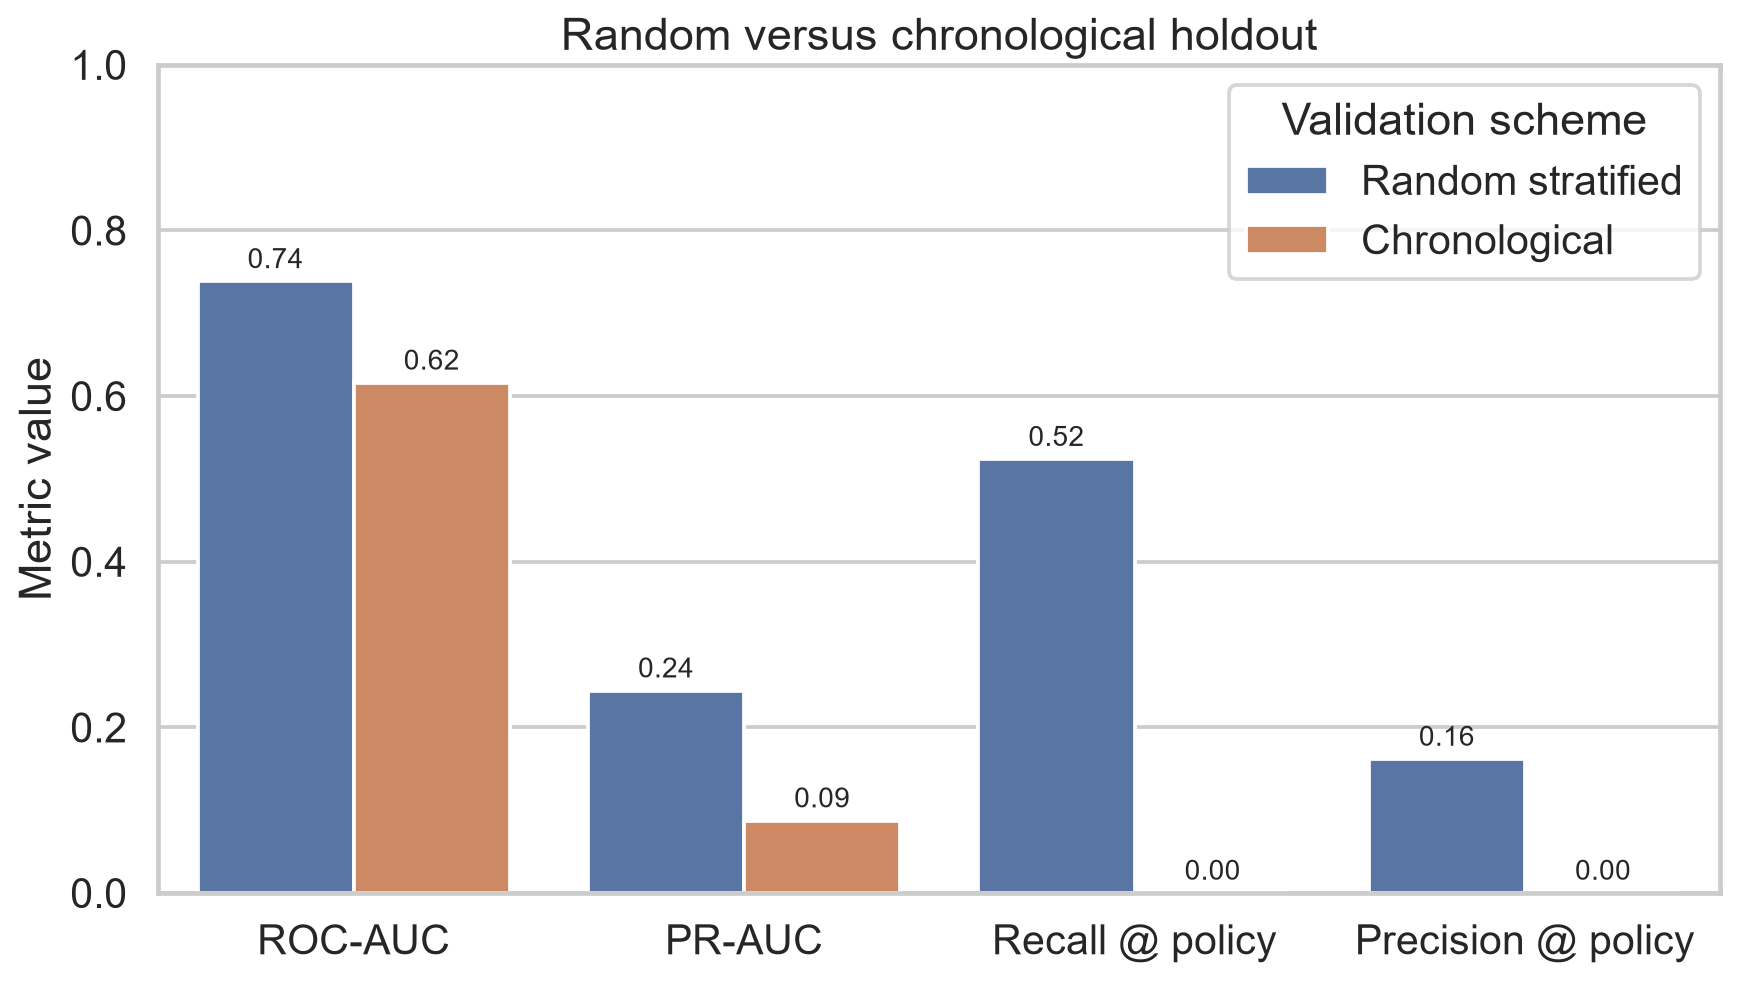

In [4]:
validation = pd.read_csv(TABLES / 'random_vs_chronological_metrics.csv')
display(validation[['validation_scheme', 'roc_auc', 'pr_auc', 'recall',
                    'precision', 'review_rate']].round(3))
display(Image(filename=str(FIGURES / 'random_vs_chronological_metrics.png'), width=950))

## 4. Bootstrap uncertainty

In [5]:
intervals = pd.read_csv(TABLES / 'bootstrap_confidence_intervals.csv')
intervals[['validation_scheme', 'metric', 'estimate', 'lower', 'upper']].round(3)

,validation_scheme,metric,estimate,lower,upper
0,random_stratified_holdout,roc_auc,0.739,0.620,0.846
1,random_stratified_holdout,pr_auc,0.244,0.130,0.433
2,random_stratified_holdout,brier_score,0.059,0.053,0.064
3,random_stratified_holdout,balanced_accuracy,0.665,0.556,0.772
4,random_stratified_holdout,precision,0.162,0.102,0.228
5,random_stratified_holdout,recall,0.524,0.333,0.714
6,chronological_holdout,roc_auc,0.616,0.480,0.760
7,chronological_holdout,pr_auc,0.087,0.061,0.170
8,chronological_holdout,brier_score,0.053,0.050,0.056
9,chronological_holdout,balanced_accuracy,0.492,0.483,0.498


## 5. Review-capacity analysis

A screening team usually has a review budget, not a universal probability
threshold. The chronological top 10% captures 17.6% of failures (1.73x
lift), and the top 20% captures 35.3%.

,validation_scheme,target_review_fraction,failures_captured,total_failures,failure_recall,review_precision,lift_vs_baseline
0,random_stratified_holdout,0.05,5,21,0.238,0.312,4.673
1,random_stratified_holdout,0.10,7,21,0.333,0.219,3.271
2,random_stratified_holdout,0.15,9,21,0.429,0.188,2.804
3,random_stratified_holdout,0.20,10,21,0.476,0.159,2.373
4,random_stratified_holdout,0.25,11,21,0.524,0.139,2.082
5,random_stratified_holdout,0.30,14,21,0.667,0.147,2.204
6,chronological_holdout,0.05,0,17,0.000,0.000,0.000
7,chronological_holdout,0.10,3,17,0.176,0.094,1.732
8,chronological_holdout,0.15,5,17,0.294,0.104,1.924
9,chronological_holdout,0.20,6,17,0.353,0.095,1.759


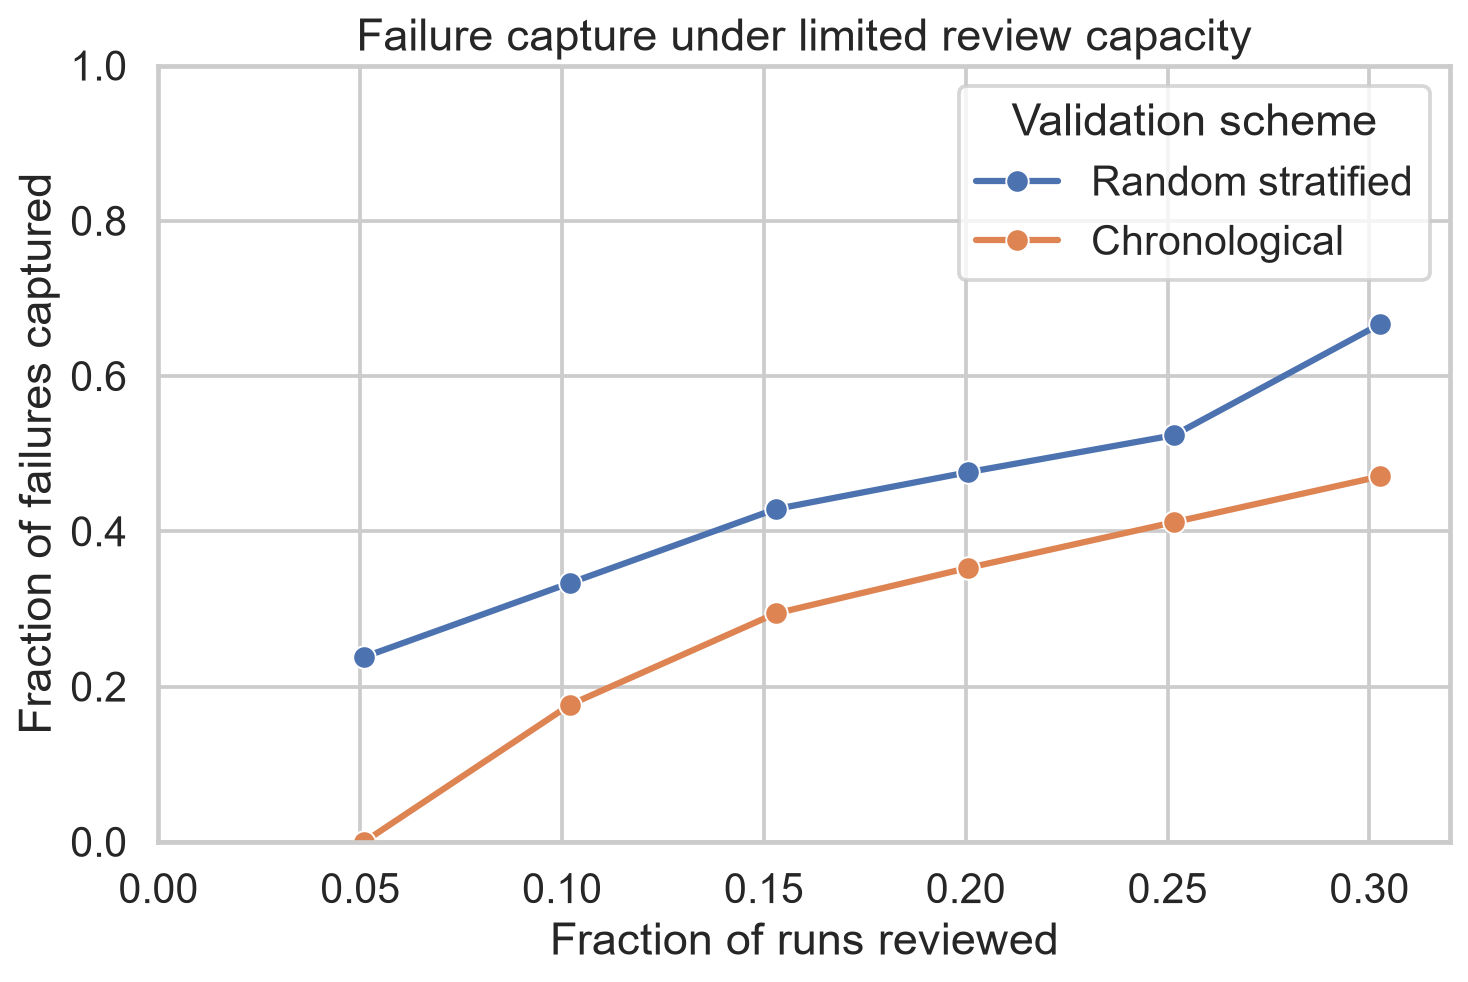

In [6]:
capacity = pd.read_csv(TABLES / 'review_capacity_analysis.csv')
display(capacity[['validation_scheme', 'target_review_fraction',
                  'failures_captured', 'total_failures', 'failure_recall',
                  'review_precision', 'lift_vs_baseline']].round(3))
display(Image(filename=str(FIGURES / 'review_capacity_curve.png'), width=850))

## 6. Cost-ratio sensitivity

Thresholds are derived from non-test predictions. The policy is highly
sensitive to the assumed missed-failure cost, and the 10:1 temporal policy
detects none of the latest 17 failures. No threshold is promoted as a
production rule.

In [7]:
cost = pd.read_csv(TABLES / 'cost_ratio_sensitivity.csv')
cost[['validation_scheme', 'fn_fp_cost_ratio', 'threshold', 'recall',
      'precision', 'false_positive', 'false_negative', 'review_rate']].round(3)

,validation_scheme,fn_fp_cost_ratio,threshold,recall,precision,false_positive,false_negative,review_rate
0,random_stratified_holdout,1,0.99,0.000,0.000,0,21,0.000
1,chronological_holdout,1,0.26,0.000,0.000,4,17,0.013
2,random_stratified_holdout,2,0.34,0.095,0.400,3,19,0.016
3,chronological_holdout,2,0.26,0.000,0.000,4,17,0.013
4,random_stratified_holdout,5,0.34,0.095,0.400,3,19,0.016
5,chronological_holdout,5,0.24,0.000,0.000,5,17,0.016
6,random_stratified_holdout,10,0.15,0.524,0.162,57,10,0.217
7,chronological_holdout,10,0.24,0.000,0.000,5,17,0.016
8,random_stratified_holdout,20,0.08,0.810,0.102,150,4,0.532
9,chronological_holdout,20,0.17,0.176,0.120,22,14,0.080


## 7. Probability calibration

Isotonic calibration is best by Brier score and five-bin calibration error,
while sigmoid calibration is best by log loss. The disagreement and small
holdout argue against promoting either probability scale.

,calibration,roc_auc,pr_auc,brier_score,log_loss,quantile_ece_5_bins
0,isotonic,0.7730,0.2688,0.0567,0.3117,0.0091
1,sigmoid,0.7682,0.2366,0.0580,0.2186,0.0277
2,uncalibrated,0.7385,0.2443,0.0590,0.2281,0.0333


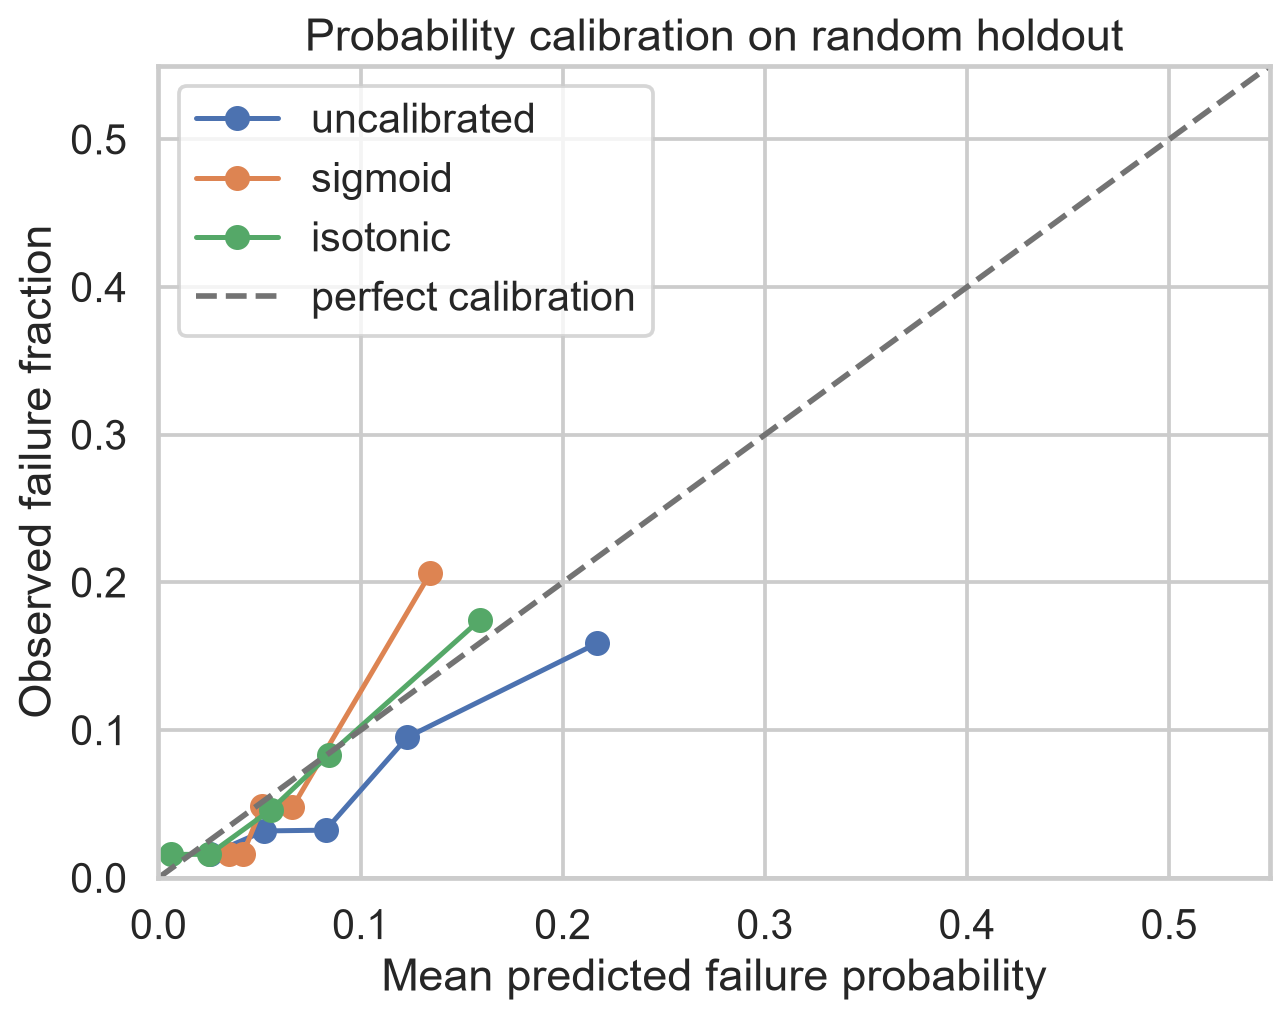

In [8]:
calibration = pd.read_csv(TABLES / 'calibration_comparison.csv')
display(calibration.round(4))
display(Image(filename=str(FIGURES / 'calibration_comparison.png'), width=750))

## 8. Feature-ranking stability

`sensor_103` and `sensor_059` rank in the model's top 20 in all 10 folds.
Held-out permutation importance independently ranks `sensor_059` first.
Anonymous variable identities prevent physical or causal interpretation.

,feature,selection_frequency,top20_frequency,mean_importance_when_top20,median_rank_when_top20,folds
0,sensor_103,1.0,1.0,0.037,1.0,10
1,sensor_059,1.0,1.0,0.032,2.0,10
2,sensor_510,1.0,0.8,0.021,5.0,10
3,sensor_064,1.0,0.8,0.019,13.0,10
4,sensor_477,0.8,0.7,0.023,5.0,10
5,sensor_213,0.8,0.7,0.020,7.0,10
6,sensor_130,0.9,0.7,0.020,6.0,10
7,sensor_281,0.8,0.7,0.019,8.0,10
8,sensor_125,1.0,0.6,0.020,13.0,10
9,sensor_021,0.9,0.6,0.020,7.5,10


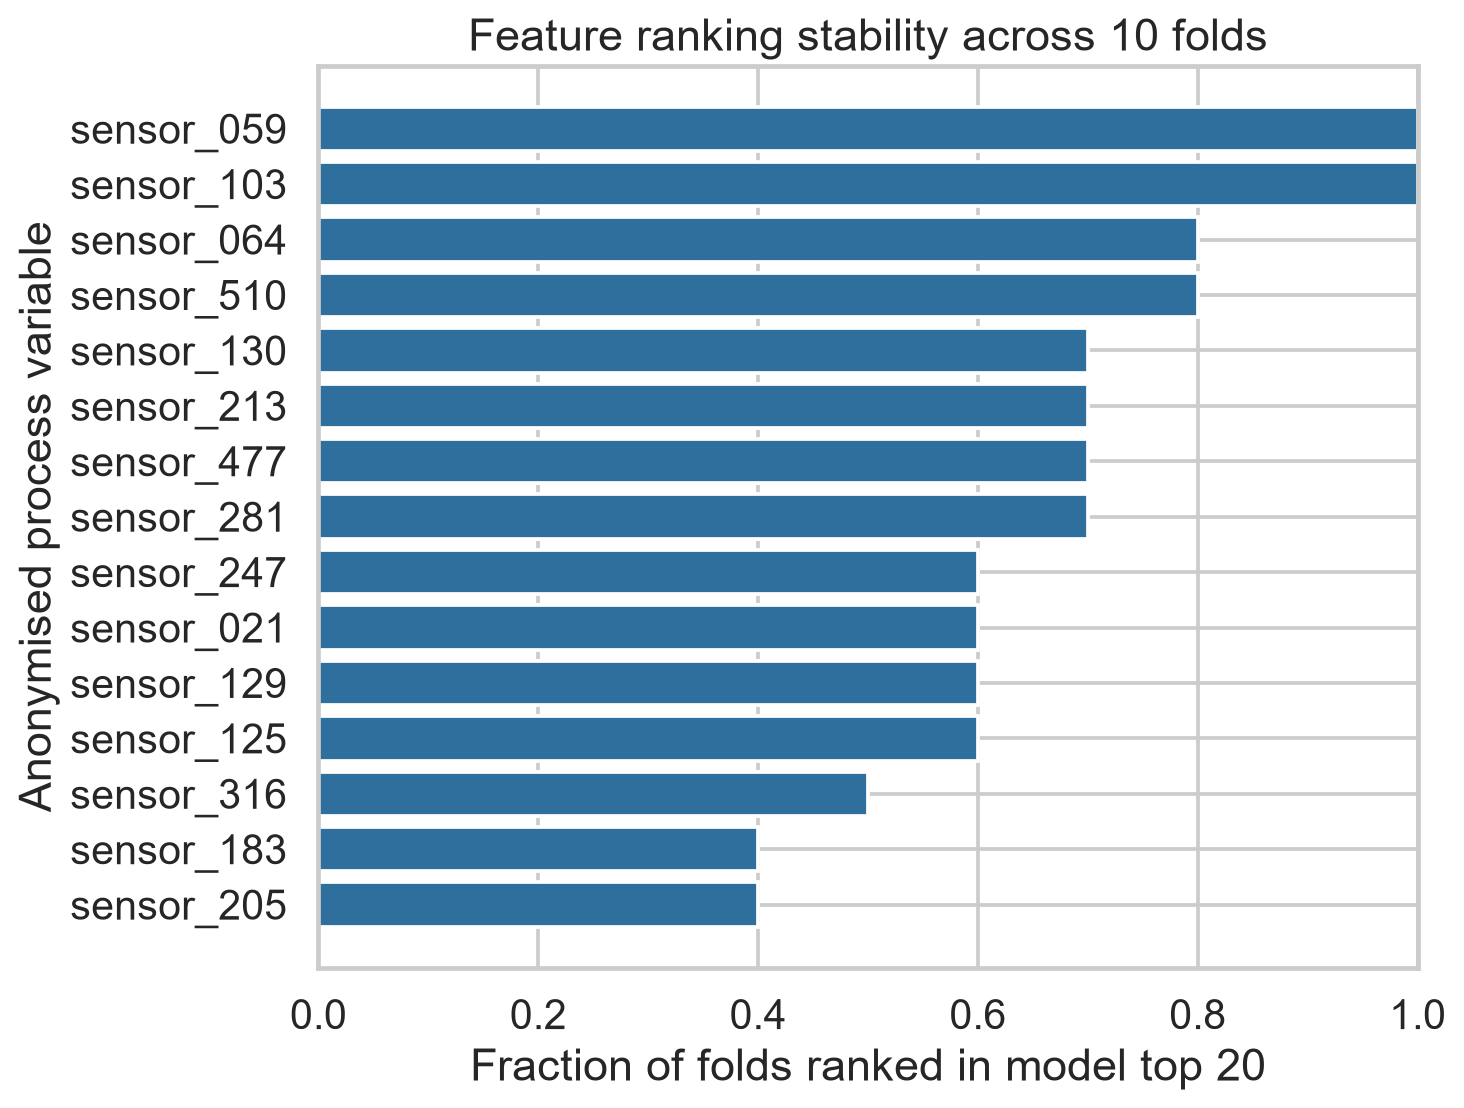

In [9]:
stability = pd.read_csv(TABLES / 'feature_stability.csv')
display(stability.head(15).round(3))
display(Image(filename=str(FIGURES / 'feature_stability.png'), width=800))

## 9. Reproduction and limits

Run `python scripts/run_baseline.py` and then
`python scripts/run_enhanced_analysis.py` from the project root. The model
card records intended use and limitations. This is a portfolio screening
workflow, not a deployable fab decision system.